# Self-Supervised Image Representation Learning using Masked Autoencoders (MAE)
## Generative AI | Assignment 2

**Architecture:** Asymmetric ViT Encoder-Decoder  
**Dataset:** TinyImageNet  
**Platform:** Kaggle (GPU T4 x2)

## 1. Environment Setup & Imports

In [1]:
# Install required packages
!pip install -q timm einops scikit-image gradio

In [ ]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import torchvision.transforms as transforms
import torchvision.datasets as datasets

from einops import rearrange, repeat
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Seed for reproducibility
def set_seed(seed=48):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(48)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'GPU count: {torch.cuda.device_count()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Using device: cuda
GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 2. Configuration

In [ ]:
class Config:
    # ── Image & Patch ──────────────────────────────────────────
    IMAGE_SIZE   = 224
    PATCH_SIZE   = 16
    NUM_PATCHES  = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 196
    MASK_RATIO   = 0.75
    NUM_VISIBLE  = int(NUM_PATCHES * (1 - MASK_RATIO))  # 49
    NUM_MASKED   = NUM_PATCHES - NUM_VISIBLE              # 147

    # ── Encoder  (ViT-Base/16  ~86 M params) ──────────────────
    ENC_DIM       = 768
    ENC_DEPTH     = 12
    ENC_HEADS     = 12
    ENC_MLP_RATIO = 4

    # ── Decoder  (ViT-Small/16 ~22 M params) ──────────────────
    DEC_DIM       = 384
    DEC_DEPTH     = 12
    DEC_HEADS     = 6
    DEC_MLP_RATIO = 4

    # ── Training ───────────────────────────────────────────────
    EPOCHS           = 60
    BATCH_SIZE       = 32
    GRAD_ACCUM_STEPS = 4        # effective batch size = 32 * 4 = 128
    LEARNING_RATE    = 1.5e-4
    WEIGHT_DECAY     = 0.05
    WARMUP_EPOCHS    = 5        # 5-epoch linear warmup
    GRAD_CLIP        = 1.0
    NUM_WORKERS      = 4

    # ── Paths (add dataset via Kaggle "+ Add Data" first) ─────
    DATA_DIR       = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'
    CHECKPOINT_DIR = '/kaggle/working/checkpoints'

cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
print(f'Num patches:            {cfg.NUM_PATCHES}')
print(f'Visible patches (25%):  {cfg.NUM_VISIBLE}')
print(f'Masked  patches (75%):  {cfg.NUM_MASKED}')
print(f'Effective batch size:   {cfg.BATCH_SIZE * cfg.GRAD_ACCUM_STEPS}')


Num patches:            196
Visible patches (25%):  49
Masked  patches (75%):  147


## 3. Dataset

In [4]:
class TinyImageNetDataset(Dataset):
    """TinyImageNet Dataset with proper val directory handling."""
    
    def __init__(self, root, split='train', transform=None):
        self.root = Path(root)
        self.split = split
        self.transform = transform
        self.samples = []
        self._load_samples()
    
    def _load_samples(self):
        if self.split == 'train':
            train_dir = self.root / 'train'
            for class_dir in sorted(train_dir.iterdir()):
                if class_dir.is_dir():
                    img_dir = class_dir / 'images'
                    if img_dir.exists():
                        for img_path in img_dir.glob('*.JPEG'):
                            self.samples.append(str(img_path))
        elif self.split == 'val':
            val_dir = self.root / 'val'
            # Try images subdirectory first
            val_img_dir = val_dir / 'images'
            if val_img_dir.exists():
                for img_path in val_img_dir.glob('*.JPEG'):
                    self.samples.append(str(img_path))
            else:
                # Walk recursively
                for img_path in val_dir.rglob('*.JPEG'):
                    self.samples.append(str(img_path))
        print(f'[{self.split}] Loaded {len(self.samples)} images')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img


def get_transforms(image_size=224, is_train=True):
    if is_train:
        return transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize(int(image_size * 1.143)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
        ])


train_dataset = TinyImageNetDataset(
    cfg.DATA_DIR, split='train',
    transform=get_transforms(cfg.IMAGE_SIZE, is_train=True)
)
val_dataset = TinyImageNetDataset(
    cfg.DATA_DIR, split='val',
    transform=get_transforms(cfg.IMAGE_SIZE, is_train=False)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True
)
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

[train] Loaded 100000 images
[val] Loaded 10000 images
Train batches: 3125, Val batches: 313


## 4. Model Architecture

### 4.1 Building Blocks

In [5]:
class PatchEmbed(nn.Module):
    """Split image into non-overlapping patches and embed them."""
    
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        # x: (B, C, H, W) -> (B, num_patches, embed_dim)
        x = self.proj(x)                    # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)                    # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)              # (B, num_patches, embed_dim)
        return x


class MultiHeadSelfAttention(nn.Module):
    """Multi-Head Self Attention from scratch."""
    
    def __init__(self, dim, num_heads=8, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)
    
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)            # each: (B, heads, N, head_dim)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)  # (B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class MLP(nn.Module):
    """Feed-Forward Network (MLP block in Transformer)."""
    
    def __init__(self, dim, mlp_ratio=4, dropout=0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.fc2 = nn.Linear(hidden, dim)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class TransformerBlock(nn.Module):
    """Standard Transformer Encoder Block."""
    
    def __init__(self, dim, num_heads, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, mlp_ratio, dropout)
    
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


def get_2d_sincos_pos_embed(embed_dim, grid_size):
    """2D sinusoidal positional embedding."""
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # (2, grid_size, grid_size)
    grid = np.stack(grid, axis=0).reshape(2, -1)  # (2, N)
    
    assert embed_dim % 2 == 0
    emb_h = _get_1d_sincos_pos_embed(embed_dim // 2, grid[0])
    emb_w = _get_1d_sincos_pos_embed(embed_dim // 2, grid[1])
    emb = np.concatenate([emb_h, emb_w], axis=1)  # (N, embed_dim)
    return torch.from_numpy(emb).float()


def _get_1d_sincos_pos_embed(embed_dim, pos):
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.0
    omega = 1.0 / (10000 ** omega)
    pos = pos.reshape(-1)
    out = np.outer(pos, omega)  # (N, embed_dim/2)
    emb = np.concatenate([np.sin(out), np.cos(out)], axis=1)  # (N, embed_dim)
    return emb

print('Building blocks defined.')

Building blocks defined.


### 4.2 MAE Encoder (ViT-Base/16)

In [6]:
class MAEEncoder(nn.Module):
    """
    MAE Encoder: ViT-Base/16
    - Patch size: 16x16
    - Embed dim: 768
    - Depth: 12
    - Heads: 12
    - Only sees 25% visible patches (NO mask tokens)
    """
    
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_chans=3,
        embed_dim=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4,
        dropout=0.0
    ):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.embed_dim = embed_dim
        
        # Patch embedding
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        
        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # Positional embedding (fixed sincos, not learnable)
        pos_embed = get_2d_sincos_pos_embed(embed_dim, img_size // patch_size)
        # Add 1 for CLS token
        cls_pos = torch.zeros(1, embed_dim)
        pos_embed = torch.cat([cls_pos, pos_embed], dim=0)  # (1+N, D)
        self.register_buffer('pos_embed', pos_embed.unsqueeze(0))  # (1, 1+N, D)
        
        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
    
    def random_masking(self, x, mask_ratio=0.75):
        """
        Perform random masking. Keep (1 - mask_ratio) fraction visible.
        Returns:
            x_visible: (B, num_visible, D) - only visible patches
            mask: (B, N) - binary mask, 1=masked, 0=visible
            ids_restore: (B, N) - indices to restore original order
        """
        B, N, D = x.shape
        num_keep = int(N * (1 - mask_ratio))
        
        # Random noise for shuffling
        noise = torch.rand(B, N, device=x.device)
        
        # Sort: small values first = visible
        ids_shuffle = noise.argsort(dim=1)
        ids_restore = ids_shuffle.argsort(dim=1)
        
        # Keep first num_keep tokens
        ids_keep = ids_shuffle[:, :num_keep]
        x_visible = torch.gather(
            x, dim=1,
            index=ids_keep.unsqueeze(-1).expand(-1, -1, D)
        )
        
        # Binary mask: 0=visible, 1=masked
        mask = torch.ones(B, N, device=x.device)
        mask[:, :num_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_visible, mask, ids_restore
    
    def forward(self, x, mask_ratio=0.75):
        # Patch embed
        x = self.patch_embed(x)                         # (B, N, D)
        
        # Add positional embedding (skip CLS position)
        x = x + self.pos_embed[:, 1:, :]               # (B, N, D)
        
        # Random masking: keep only visible
        x, mask, ids_restore = self.random_masking(x, mask_ratio)
        
        # Prepend CLS token
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        cls = cls + self.pos_embed[:, :1, :]
        x = torch.cat([cls, x], dim=1)                 # (B, 1+num_visible, D)
        
        # Transformer
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        
        return x, mask, ids_restore


# Quick param count
enc = MAEEncoder(embed_dim=cfg.ENC_DIM, depth=cfg.ENC_DEPTH, num_heads=cfg.ENC_HEADS)
enc_params = sum(p.numel() for p in enc.parameters()) / 1e6
print(f'Encoder parameters: {enc_params:.1f}M')
del enc

Encoder parameters: 85.6M


### 4.3 MAE Decoder (ViT-Small/16)

In [7]:
class MAEDecoder(nn.Module):
    """
    MAE Decoder: ViT-Small/16
    - Embed dim: 384
    - Depth: 12
    - Heads: 6
    - Reconstructs full image from visible + mask tokens
    """
    
    def __init__(
        self,
        num_patches=196,
        patch_size=16,
        encoder_dim=768,
        decoder_dim=384,
        decoder_depth=12,
        decoder_heads=6,
        mlp_ratio=4,
        dropout=0.0
    ):
        super().__init__()
        self.num_patches = num_patches
        self.patch_size = patch_size
        self.decoder_dim = decoder_dim
        
        # Project encoder output to decoder dimension
        self.encoder_to_decoder = nn.Linear(encoder_dim, decoder_dim)
        
        # Learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        
        # Decoder positional embedding (fixed sincos)
        grid_size = int(num_patches ** 0.5)
        pos_embed = get_2d_sincos_pos_embed(decoder_dim, grid_size)
        cls_pos = torch.zeros(1, decoder_dim)
        pos_embed = torch.cat([cls_pos, pos_embed], dim=0)  # (1+N, D)
        self.register_buffer('pos_embed', pos_embed.unsqueeze(0))
        
        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(decoder_dim, decoder_heads, mlp_ratio, dropout)
            for _ in range(decoder_depth)
        ])
        self.norm = nn.LayerNorm(decoder_dim)
        
        # Prediction head: map each patch token to pixel values
        pixel_per_patch = patch_size * patch_size * 3
        self.pred_head = nn.Linear(decoder_dim, pixel_per_patch)
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, encoder_output, ids_restore):
        """
        Args:
            encoder_output: (B, 1+num_visible, encoder_dim) - includes CLS token
            ids_restore: (B, N) - indices to restore original order
        Returns:
            pred: (B, N, patch_size^2 * 3) - pixel predictions for all patches
        """
        B = encoder_output.shape[0]
        N = self.num_patches
        
        # Project encoder tokens to decoder dim
        x = self.encoder_to_decoder(encoder_output)  # (B, 1+num_visible, D_dec)
        
        # Separate CLS from patch tokens
        cls_token = x[:, :1, :]       # (B, 1, D_dec)
        patch_tokens = x[:, 1:, :]   # (B, num_visible, D_dec)
        
        num_visible = patch_tokens.shape[1]
        num_masked = N - num_visible
        
        # Expand mask tokens for all masked positions
        mask_tokens = self.mask_token.expand(B, num_masked, -1)  # (B, num_masked, D_dec)
        
        # Concatenate visible + mask tokens
        full_tokens = torch.cat([patch_tokens, mask_tokens], dim=1)  # (B, N, D_dec)
        
        # Restore original patch order using ids_restore
        full_tokens = torch.gather(
            full_tokens, dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, self.decoder_dim)
        )  # (B, N, D_dec)
        
        # Add decoder positional embeddings
        full_tokens = full_tokens + self.pos_embed[:, 1:, :]  # skip CLS pos
        
        # Prepend CLS token with positional embedding
        cls_token = cls_token + self.pos_embed[:, :1, :]
        full_tokens = torch.cat([cls_token, full_tokens], dim=1)  # (B, 1+N, D_dec)
        
        # Transformer
        for blk in self.blocks:
            full_tokens = blk(full_tokens)
        full_tokens = self.norm(full_tokens)
        
        # Prediction: drop CLS, apply head
        patch_out = full_tokens[:, 1:, :]  # (B, N, D_dec)
        pred = self.pred_head(patch_out)   # (B, N, patch_size^2 * 3)
        
        return pred


# Quick param count
dec = MAEDecoder(
    num_patches=cfg.NUM_PATCHES,
    patch_size=cfg.PATCH_SIZE,
    encoder_dim=cfg.ENC_DIM,
    decoder_dim=cfg.DEC_DIM,
    decoder_depth=cfg.DEC_DEPTH,
    decoder_heads=cfg.DEC_HEADS
)
dec_params = sum(p.numel() for p in dec.parameters()) / 1e6
print(f'Decoder parameters: {dec_params:.1f}M')
del dec

Decoder parameters: 21.9M


### 4.4 Complete MAE Model

In [8]:
class MaskedAutoencoder(nn.Module):
    """Complete MAE: Encoder + Decoder with patchification utilities."""
    
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        
        self.encoder = MAEEncoder(
            img_size=cfg.IMAGE_SIZE,
            patch_size=cfg.PATCH_SIZE,
            embed_dim=cfg.ENC_DIM,
            depth=cfg.ENC_DEPTH,
            num_heads=cfg.ENC_HEADS,
            mlp_ratio=cfg.ENC_MLP_RATIO
        )
        
        self.decoder = MAEDecoder(
            num_patches=cfg.NUM_PATCHES,
            patch_size=cfg.PATCH_SIZE,
            encoder_dim=cfg.ENC_DIM,
            decoder_dim=cfg.DEC_DIM,
            decoder_depth=cfg.DEC_DEPTH,
            decoder_heads=cfg.DEC_HEADS,
            mlp_ratio=cfg.DEC_MLP_RATIO
        )
    
    def patchify(self, imgs):
        """
        Convert image tensor to patches.
        imgs: (B, 3, H, W)
        return: (B, N, patch_size^2 * 3)
        """
        p = self.cfg.PATCH_SIZE
        assert imgs.shape[2] == imgs.shape[3]  # square
        h = w = imgs.shape[2] // p
        
        x = imgs.reshape(imgs.shape[0], 3, h, p, w, p)
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(imgs.shape[0], h * w, p * p * 3)
        return x
    
    def unpatchify(self, patches):
        """
        Convert patches back to image.
        patches: (B, N, patch_size^2 * 3)
        return: (B, 3, H, W)
        """
        p = self.cfg.PATCH_SIZE
        h = w = int(patches.shape[1] ** 0.5)
        
        x = patches.reshape(patches.shape[0], h, w, p, p, 3)
        x = torch.einsum('nhwpqc->nchpwq', x)
        x = x.reshape(patches.shape[0], 3, h * p, w * p)
        return x
    
    def compute_loss(self, imgs, pred, mask):
        """
        MSE loss only on masked patches.
        imgs:  (B, 3, H, W)
        pred:  (B, N, patch_size^2 * 3)
        mask:  (B, N) - 1=masked, 0=visible
        """
        target = self.patchify(imgs)       # (B, N, p^2*3)
        
        # Normalize target per-patch (as in original MAE paper)
        mean = target.mean(dim=-1, keepdim=True)
        var  = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()
        
        loss = (pred - target) ** 2        # (B, N, p^2*3)
        loss = loss.mean(dim=-1)           # (B, N)
        
        # Only masked patches
        loss = (loss * mask).sum() / mask.sum()
        return loss
    
    def forward(self, imgs, mask_ratio=0.75):
        # Encode visible patches
        enc_out, mask, ids_restore = self.encoder(imgs, mask_ratio)
        
        # Decode: reconstruct all patches
        pred = self.decoder(enc_out, ids_restore)
        
        # Compute loss on masked patches
        loss = self.compute_loss(imgs, pred, mask)
        
        return loss, pred, mask


# Build the full model
model = MaskedAutoencoder(cfg)

# Multi-GPU if available
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs!')
    model = nn.DataParallel(model)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Total parameters: {total_params:.1f}M')

Using 2 GPUs!
Total parameters: 107.5M


## 5. Training Setup

In [ ]:
def get_optimizer_and_scheduler(model, cfg):
    # Separate parameters: weight decay vs no weight decay
    decay_params = []
    no_decay_params = []
    
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if 'norm' in name or 'bias' in name or 'pos_embed' in name or \
           'cls_token' in name or 'mask_token' in name:
            no_decay_params.append(param)
        else:
            decay_params.append(param)
    
    param_groups = [
        {'params': decay_params,    'weight_decay': cfg.WEIGHT_DECAY},
        {'params': no_decay_params, 'weight_decay': 0.0}
    ]
    
    optimizer = torch.optim.AdamW(
        param_groups,
        lr=cfg.LEARNING_RATE,
        betas=(0.9, 0.95)
    )
    
    # CosineAnnealingLR with 5-epoch linear warmup via SequentialLR
    warmup_scheduler = LinearLR(
        optimizer, start_factor=1e-3, end_factor=1.0,
        total_iters=cfg.WARMUP_EPOCHS
    )
    cosine_scheduler = CosineAnnealingLR(
        optimizer, T_max=cfg.EPOCHS - cfg.WARMUP_EPOCHS, eta_min=1e-6
    )
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[cfg.WARMUP_EPOCHS]
    )
    
    return optimizer, scheduler


optimizer, scheduler = get_optimizer_and_scheduler(model, cfg)
scaler = GradScaler('cuda')  # For mixed precision

print('Optimizer : AdamW (weight decay = %.2f)' % cfg.WEIGHT_DECAY)
print('Scheduler : CosineAnnealingLR + 5-epoch linear warmup')
print('Mixed precision  : enabled (torch.amp)')
print('Grad accumulation: %d steps (effective batch = %d)' % (
    cfg.GRAD_ACCUM_STEPS, cfg.BATCH_SIZE * cfg.GRAD_ACCUM_STEPS))

Optimizer: AdamW
Scheduler: Cosine with warmup
Mixed precision: enabled


/tmp/ipykernel_55/3735208953.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision


## 6. Training Loop

In [ ]:
def train_one_epoch(model, loader, optimizer, scaler, device, cfg):
    model.train()
    total_loss = 0.0
    num_batches = 0
    accum_steps = cfg.GRAD_ACCUM_STEPS

    optimizer.zero_grad()
    pbar = tqdm(loader, desc='Training', leave=False)
    for batch_idx, imgs in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)

        with autocast(device_type='cuda'):
            loss, pred, mask = model(imgs, mask_ratio=cfg.MASK_RATIO)
            if isinstance(loss, torch.Tensor) and loss.dim() > 0:
                loss = loss.mean()
            loss = loss / accum_steps          # scale for accumulation

        scaler.scale(loss).backward()

        if (batch_idx + 1) % accum_steps == 0:
            # Gradient clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * accum_steps   # unscaled for logging
        num_batches += 1
        pbar.set_postfix({'loss': f'{loss.item() * accum_steps:.4f}'})

    # Handle leftover gradients if loader length isn't divisible by accum_steps
    if num_batches % accum_steps != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    return total_loss / num_batches


@torch.no_grad()
def validate(model, loader, device, cfg):
    model.eval()
    total_loss = 0.0
    num_batches = 0

    for imgs in tqdm(loader, desc='Validating', leave=False):
        imgs = imgs.to(device, non_blocking=True)

        with autocast(device_type='cuda'):
            loss, pred, mask = model(imgs, mask_ratio=cfg.MASK_RATIO)
            if isinstance(loss, torch.Tensor) and loss.dim() > 0:
                loss = loss.mean()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches


# --- Training ---
train_losses = []
val_losses = []
best_val_loss = float('inf')

print('=' * 60)
print('Starting Training')
print(f'  Epochs           : {cfg.EPOCHS}')
print(f'  Batch size       : {cfg.BATCH_SIZE}')
print(f'  Grad accum steps : {cfg.GRAD_ACCUM_STEPS}')
print(f'  Effective batch  : {cfg.BATCH_SIZE * cfg.GRAD_ACCUM_STEPS}')
print('=' * 60)

for epoch in range(cfg.EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, device, cfg)
    val_loss   = validate(model, val_loader, device, cfg)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    lr = optimizer.param_groups[0]['lr']
    print(f'Epoch [{epoch+1:3d}/{cfg.EPOCHS}] | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'LR: {lr:.6f}')

    # Save model every epoch
    torch.save(model.state_dict(), f"/kaggle/working/model_epoch_{epoch+1}.pth")

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        ckpt_path = os.path.join(cfg.CHECKPOINT_DIR, 'mae_best.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, ckpt_path)
        print(f'  --> New best checkpoint saved (val_loss={val_loss:.4f})')

print('\nTraining complete!')
print(f'Best val loss: {best_val_loss:.4f}')

Starting Training


Training:   0%|          | 0/3125 [00:00<?, ?it/s]/tmp/ipykernel_55/2921512479.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
Validating:   0%|          | 0/313 [00:00<?, ?it/s]                       /tmp/ipykernel_55/2921512479.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [  1/30] | Train Loss: 1.6908 | Val Loss: 1.6855 | LR: 0.000021
  --> New best checkpoint saved (val_loss=1.6855)


Epoch [  2/30] | Train Loss: 0.6328 | Val Loss: 0.5983 | LR: 0.000043
  --> New best checkpoint saved (val_loss=0.5983)


Epoch [  3/30] | Train Loss: 0.5028 | Val Loss: 0.5027 | LR: 0.000064
  --> New best checkpoint saved (val_loss=0.5027)


...

Epoch [ 26/30] | Train Loss: 0.3047 | Val Loss: 0.3239 | LR: 0.000011
  --> New best checkpoint saved (val_loss=0.3239)


Epoch [ 27/30] | Train Loss: 0.3031 | Val Loss: 0.3233 | LR: 0.000006
  --> New best checkpoint saved (val_loss=0.3233)


Epoch [ 28/30] | Train Loss: 0.3023 | Val Loss: 0.3219 | LR: 0.000003
  --> New best checkpoint saved (val_loss=0.3219)


Epoch [ 29/30] | Train Loss: 0.3022 | Val Loss: 0.3215 | LR: 0.000001
  --> New best checkpoint saved (val_loss=0.3215)


Epoch [ 30/30] | Train Loss: 0.3023 | Val Loss: 0.3217 | LR: 0.000000

Training complete!
Best val loss: 0.3215


## 7. Training Loss Plot

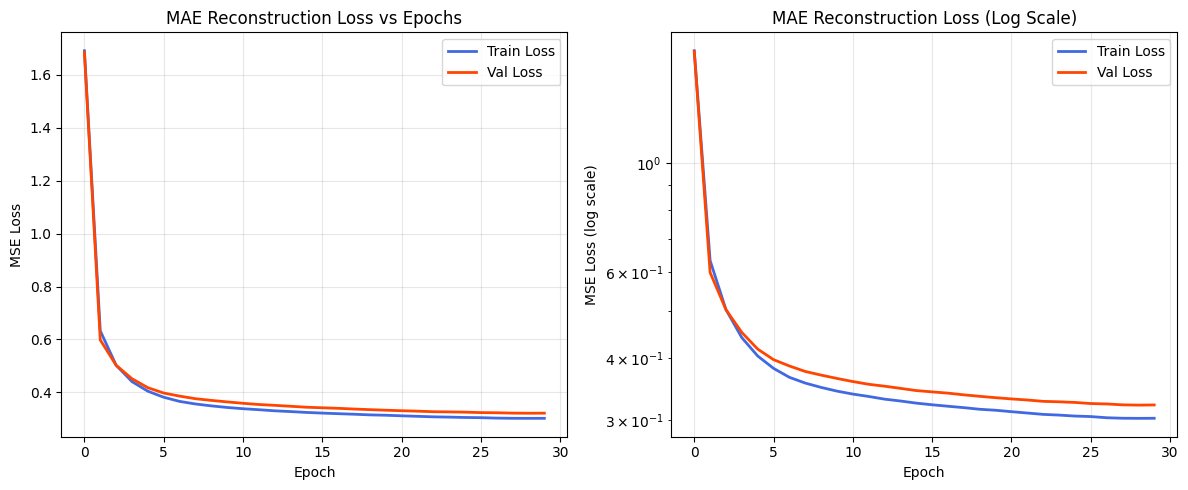

Loss plot saved.


In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='royalblue', linewidth=2)
plt.plot(val_losses, label='Val Loss', color='orangered', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('MAE Reconstruction Loss vs Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', color='royalblue', linewidth=2)
plt.plot(val_losses, label='Val Loss', color='orangered', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (log scale)')
plt.title('MAE Reconstruction Loss (Log Scale)')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss plot saved.')

## 8. Visualization

Loaded best model from epoch 29


/tmp/ipykernel_55/1583229184.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


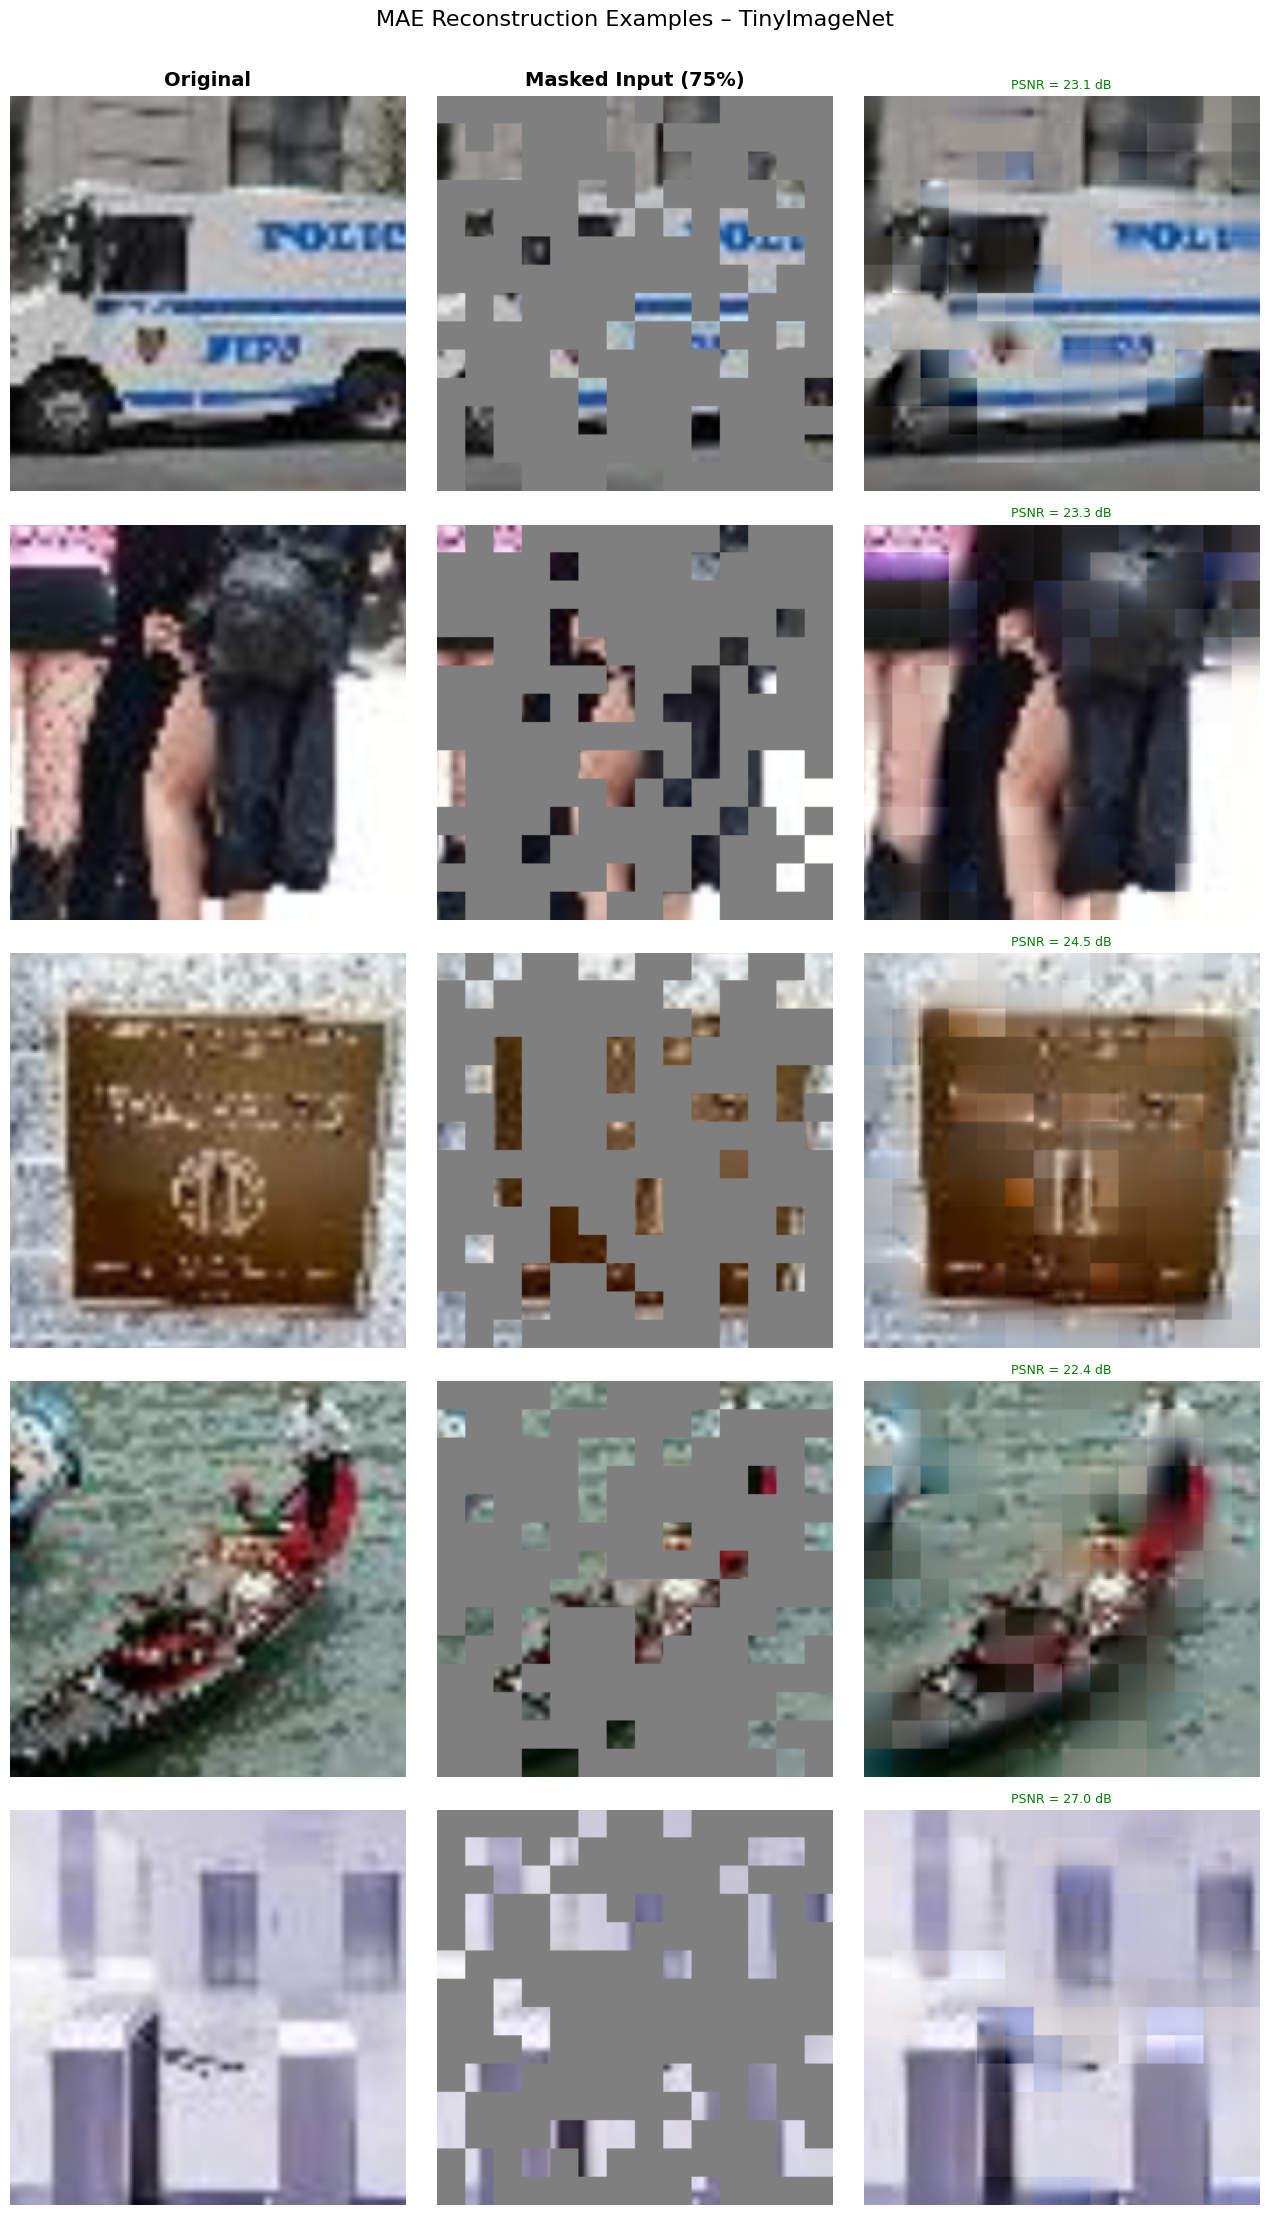

Visualisation saved.


In [ ]:
# ── Load best checkpoint ────────────────────────────────────────────────────
ckpt = torch.load(os.path.join(cfg.CHECKPOINT_DIR, 'mae_best.pth'),
                  map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded best model from epoch {ckpt["epoch"]+1}')


# ── Utility helpers ─────────────────────────────────────────────────────────
def denormalize(tensor):
    """Reverse ImageNet normalisation  ->  [0, 1] float tensor."""
    mean = torch.tensor([0.485, 0.456, 0.406], device=tensor.device).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=tensor.device).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)


def make_masked_image(img, mask, patch_size=16):
    """
    Grey-out masked patch positions for visualisation.
    img  : (3, H, W) float tensor in [0,1]
    mask : (N,) – 1 = masked, 0 = visible
    """
    img_out = img.clone()
    n = img.shape[1] // patch_size       # grid side length
    mask_2d = mask.reshape(n, n)
    for i in range(n):
        for j in range(n):
            if mask_2d[i, j] == 1:
                img_out[:, i*patch_size:(i+1)*patch_size,
                           j*patch_size:(j+1)*patch_size] = 0.5
    return img_out


@torch.no_grad()
def get_reconstruction(model, img_tensor, mask_ratio=0.75):
    """
    End-to-end reconstruction for ONE image.

    img_tensor : (1, 3, H, W)  –  ImageNet-normalised

    Returns three numpy arrays (H, W, 3) in [0, 1]:
        original   – ground truth
        masked     – original with masked patches greyed out
        recon      – visible patches from original PLUS
                     predicted patches for masked regions
                     (per-patch un-normalisation applied)
    """
    m = model.module if hasattr(model, 'module') else model

    with autocast(device_type='cuda'):
        enc_out, mask, ids_restore = m.encoder(img_tensor, mask_ratio)
        pred = m.decoder(enc_out, ids_restore)  # (1, N, p^2*3)  in patch-norm space

    # ── 1. Compute per-patch mean / std from the ORIGINAL image ─
    target_patches = m.patchify(img_tensor)               # (1, N, p^2*3)
    patch_mean = target_patches.mean(dim=-1, keepdim=True)
    patch_std  = (target_patches.var(dim=-1, keepdim=True) + 1e-6).sqrt()

    # ── 2. Un-normalise decoder output -> ImageNet-norm space ───
    pred_unnorm = pred * patch_std + patch_mean            # (1, N, p^2*3)

    # ── 3. Blend: visible = original, masked = predicted ────────
    mask_exp = mask.unsqueeze(-1)                          # (1, N, 1)
    blended  = target_patches * (1 - mask_exp) + pred_unnorm * mask_exp
    recon_img = m.unpatchify(blended)                      # (1, 3, H, W)

    # ── 4. Denormalise ImageNet stats -> [0, 1] ─────────────────
    orig  = denormalize(img_tensor.squeeze(0).cpu())
    recon = denormalize(recon_img.squeeze(0).cpu())
    masked_vis = make_masked_image(orig.clone(), mask.squeeze(0).cpu(), cfg.PATCH_SIZE)

    to_np = lambda t: np.clip(t.numpy().transpose(1, 2, 0), 0, 1)
    return to_np(orig), to_np(masked_vis), to_np(recon)


# ── Visualise 5 examples ────────────────────────────────────────────────────
val_iter   = iter(val_loader)
sample_batch = next(val_iter)[:5].to(device)

fig, axes = plt.subplots(5, 3, figsize=(13, 22))
col_titles = ['Original', 'Masked Input (75%)', 'MAE Reconstruction']
for col_idx, title in enumerate(col_titles):
    axes[0, col_idx].set_title(title, fontsize=14, fontweight='bold', pad=8)

for i in range(5):
    orig, masked, recon = get_reconstruction(
        model, sample_batch[i:i+1], mask_ratio=cfg.MASK_RATIO)

    for col_idx, img in enumerate([orig, masked, recon]):
        axes[i, col_idx].imshow(img)
        axes[i, col_idx].axis('off')
        if col_idx == 2:        # add per-sample PSNR on reconstruction column
            p_val = psnr(orig, recon, data_range=1.0)
            axes[i, col_idx].set_title(f'PSNR = {p_val:.1f} dB',
                                       fontsize=9, color='green')

plt.suptitle('MAE Reconstruction Examples – TinyImageNet', fontsize=16, y=1.005)
plt.tight_layout()
plt.savefig('/kaggle/working/reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisation saved.')

## 9. Quantitative Evaluation (PSNR & SSIM)

Computing Metrics:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_55/2047172409.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Computing Metrics: 100%|██████████| 20/20 [00:07<00:00,  2.61it/s]


Quantitative Evaluation Results
Samples evaluated : 640
PSNR  : 25.34 +/- 3.31 dB
SSIM  : 0.7579 +/- 0.0885


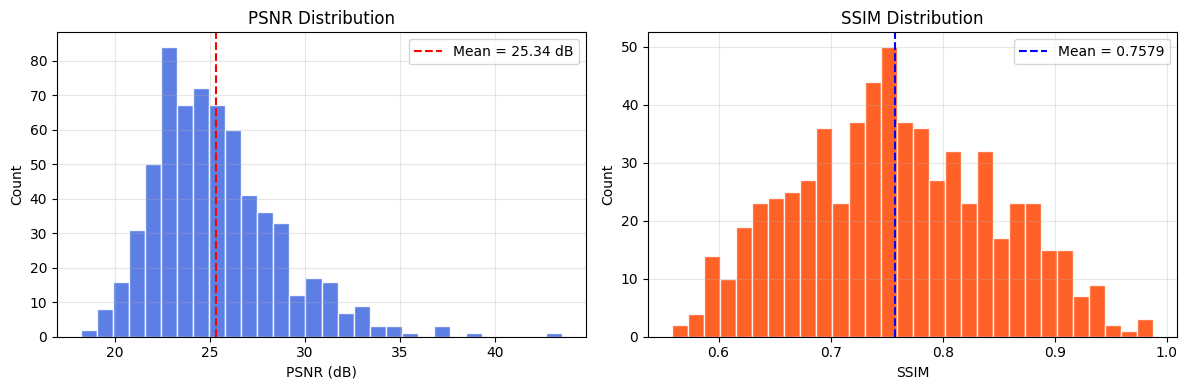

In [ ]:
@torch.no_grad()
def compute_metrics(model, loader, device, cfg, num_batches=20):
    """
    Compute PSNR and SSIM for (num_batches * batch_size) validation images.
    Uses the same per-patch un-normalisation + blending as get_reconstruction.
    """
    model.eval()
    m = model.module if hasattr(model, 'module') else model

    psnr_scores, ssim_scores = [], []

    for batch_idx, imgs in enumerate(
            tqdm(loader, total=num_batches, desc='Computing Metrics')):
        if batch_idx >= num_batches:
            break

        imgs = imgs.to(device)

        with autocast(device_type='cuda'):
            enc_out, mask, ids_restore = m.encoder(imgs, cfg.MASK_RATIO)
            pred = m.decoder(enc_out, ids_restore)          # (B, N, p^2*3)

        # Per-patch un-normalisation
        target_patches = m.patchify(imgs)
        patch_mean = target_patches.mean(dim=-1, keepdim=True)
        patch_std  = (target_patches.var(dim=-1, keepdim=True) + 1e-6).sqrt()
        pred_unnorm = pred * patch_std + patch_mean

        # Blend visible + reconstructed patches
        mask_exp  = mask.unsqueeze(-1)
        blended   = target_patches * (1 - mask_exp) + pred_unnorm * mask_exp
        pred_imgs = m.unpatchify(blended)                   # (B, 3, H, W)

        for i in range(imgs.shape[0]):
            orig_np = np.clip(
                denormalize(imgs[i].cpu()).numpy().transpose(1, 2, 0), 0, 1)
            pred_np = np.clip(
                denormalize(pred_imgs[i].cpu()).numpy().transpose(1, 2, 0), 0, 1)

            psnr_scores.append(psnr(orig_np, pred_np, data_range=1.0))
            ssim_scores.append(ssim(orig_np, pred_np, data_range=1.0, channel_axis=2))

    return np.array(psnr_scores), np.array(ssim_scores)


psnr_scores, ssim_scores = compute_metrics(
    model, val_loader, device, cfg, num_batches=20)

print('=' * 50)
print('Quantitative Evaluation Results')
print('=' * 50)
print(f'Samples evaluated : {len(psnr_scores)}')
print(f'PSNR  : {psnr_scores.mean():.2f} +/- {psnr_scores.std():.2f} dB')
print(f'SSIM  : {ssim_scores.mean():.4f} +/- {ssim_scores.std():.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(psnr_scores, bins=30, color='royalblue', edgecolor='white', alpha=0.85)
ax1.axvline(psnr_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {psnr_scores.mean():.2f} dB')
ax1.set_xlabel('PSNR (dB)')
ax1.set_ylabel('Count')
ax1.set_title('PSNR Distribution')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.hist(ssim_scores, bins=30, color='orangered', edgecolor='white', alpha=0.85)
ax2.axvline(ssim_scores.mean(), color='blue', linestyle='--',
            label=f'Mean = {ssim_scores.mean():.4f}')
ax2.set_xlabel('SSIM')
ax2.set_ylabel('Count')
ax2.set_title('SSIM Distribution')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/metrics_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. App Deployment (Gradio)

In [14]:
import gradio as gr

# Save model weights for the app
torch.save(model.state_dict(), '/kaggle/working/mae_gradio.pth')


def preprocess_image(pil_image, image_size=224):
    """PIL RGB image -> (1, 3, H, W) ImageNet-normalised tensor."""
    tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    return tf(pil_image).unsqueeze(0)


def reconstruct_image(pil_image, mask_ratio_pct):
    """
    Gradio callback.
    Uses the corrected get_reconstruction (per-patch un-norm + blending).
    Returns:  masked PIL image, reconstructed PIL image, metrics string.
    """
    if pil_image is None:
        return None, None, 'Please upload an image first.'

    mr = max(0.10, min(0.95, float(mask_ratio_pct) / 100.0))

    img_t = preprocess_image(pil_image).to(device)
    orig_np, masked_np, recon_np = get_reconstruction(model, img_t, mask_ratio=mr)

    p_score = psnr(orig_np, recon_np, data_range=1.0)
    s_score = ssim(orig_np, recon_np, data_range=1.0, channel_axis=2)

    metrics = (f'Mask Ratio : {mr*100:.0f}%\n'
               f'PSNR       : {p_score:.2f} dB\n'
               f'SSIM       : {s_score:.4f}')

    to_pil = lambda a: Image.fromarray((a * 255).astype('uint8'))
    return to_pil(masked_np), to_pil(recon_np), metrics


# ── Build Gradio UI ─────────────────────────────────────────────────────────
with gr.Blocks(title='MAE Image Reconstruction', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # Masked Autoencoder (MAE) – Image Reconstruction
    **AI4009 Assignment 2 | FAST-NUCES**
    Upload any image and adjust the masking ratio.
    The model reconstructs the missing 16x16 patch regions.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            inp_img    = gr.Image(type='pil', label='Upload Image')
            mask_slide = gr.Slider(minimum=10, maximum=95, value=75, step=5,
                                   label='Masking Ratio (%)')
            run_btn    = gr.Button('Reconstruct', variant='primary')

        with gr.Column(scale=1):
            out_masked = gr.Image(type='pil', label='Masked Input')
            out_recon  = gr.Image(type='pil', label='MAE Reconstruction')
            out_metrics = gr.Textbox(label='Metrics', lines=3)

    run_btn.click(fn=reconstruct_image,
                  inputs=[inp_img, mask_slide],
                  outputs=[out_masked, out_recon, out_metrics])

    gr.Markdown('---\n**Architecture:** ViT-Base Encoder (86M) + ViT-Small Decoder (22M) | Dataset: TinyImageNet')

demo.launch(share=True, server_name='0.0.0.0', server_port=7860)
print('Gradio app launched.')


/tmp/ipykernel_55/2233352942.py:44: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='MAE Image Reconstruction', theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://9a3578fcb8c545ff06.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio app launched.


## 11. Save Final Model

In [15]:
# ── Save final checkpoint with full metadata ─────────────────────────────────
final_ckpt = {
    'model_state_dict': model.state_dict(),
    'config': {
        'image_size'  : cfg.IMAGE_SIZE,
        'patch_size'  : cfg.PATCH_SIZE,
        'enc_dim'     : cfg.ENC_DIM,
        'enc_depth'   : cfg.ENC_DEPTH,
        'enc_heads'   : cfg.ENC_HEADS,
        'dec_dim'     : cfg.DEC_DIM,
        'dec_depth'   : cfg.DEC_DEPTH,
        'dec_heads'   : cfg.DEC_HEADS,
        'mask_ratio'  : cfg.MASK_RATIO,
    },
    'metrics': {
        'psnr_mean'     : float(psnr_scores.mean()),
        'psnr_std'      : float(psnr_scores.std()),
        'ssim_mean'     : float(ssim_scores.mean()),
        'ssim_std'      : float(ssim_scores.std()),
        'best_val_loss' : float(best_val_loss),
        'train_losses'  : train_losses,
        'val_losses'    : val_losses,
    },
}

torch.save(final_ckpt, '/kaggle/working/mae_final.pth')
print('Final model saved  ->  /kaggle/working/mae_final.pth')

print()
print('=' * 60)
print('  TRAINING SUMMARY')
print('=' * 60)
print(f'  Architecture : ViT-Base/16 Encoder + ViT-Small/16 Decoder')
print(f'  Mask ratio   : {cfg.MASK_RATIO*100:.0f}%')
print(f'  Epochs       : {cfg.EPOCHS}')
print(f'  Best val MSE : {best_val_loss:.4f}')
print(f'  PSNR         : {psnr_scores.mean():.2f} dB')
print(f'  SSIM         : {ssim_scores.mean():.4f}')
print('=' * 60)


Final model saved  ->  /kaggle/working/mae_final.pth

  TRAINING SUMMARY
  Architecture : ViT-Base/16 Encoder + ViT-Small/16 Decoder
  Mask ratio   : 75%
  Epochs       : 30
  Best val MSE : 0.3215
  PSNR         : 25.34 dB
  SSIM         : 0.7579
